Turnir Tizimi (Chess/FIFA e.g.)

In [56]:
import random
import csv
import json
from abc import ABC, abstractmethod



class PlayerState(ABC):

    @abstractmethod
    def performance_multiplier(self):
        pass

    @abstractmethod
    def state_name(self):
        pass

#Good Form State
class GoodFormState(PlayerState):
    def performance_multiplier(self):
        return 1.5
    
    def state_name(self):
        return "Good Form"
    
#Normal Form State
class NormalFormState(PlayerState):
    def performance_multiplier(self):
        return 1.0
    
    def state_name(self):
        return "Normal Form"
    
#Bad Form State
class BadFormState(PlayerState):
    def performance_multiplier(self):
        return 0.5
    
    def state_name(self):
        return "Bad Form"
    

#MULTIPLE INHERITANCE
#Person Class - hop bu joyda 2ta class dan inhhert qilinadi: 
#Person va Statistics class laridan
class Person:
    def __init__(self, name):
        self.name = name

class Statistics:
    def __init__(self):
        self.matches_played = 0
        self.wins = 0
        self.losses = 0
        self.goals = 0
        self.points = 0

class Player(Person, Statistics):
    def __init__(self, name):
        Person.__init__(self, name)
        Statistics.__init__(self)
        
        self.state = NormalFormState()
    
    def score_goal(self):
        self.goals += 1

    def add_win(self):
        self.wins += 1
        self.points += 3

    def add_loss(self):
        self.losses += 1

    def info(self):
        return {
            "name": self.name,
            "matches": self.matches_played,
            "wins": self.wins,
            "lossses": self.losses,
            "goals": self.goals,
            "points": self.points,
            "state": self.state.state_name()
        }
    


class Referee:
    def __init__(self, name, experience):
        self.name = name
        self.experience = experience

    def start_match(self):
        print(f"Referee {self.name} started the match")

    def end_match(self):
        print(f"Referee {self.name} ended the match")


class Match:
    def __init__(self, player1, player2, referee):
        self.player1 = player1
        self.player2 = player2
        self.referee = referee

        self.score1 = 0
        self.score2 = 0

        self.winner = None

    def play_match(self):
        
        self.referee.start_match()

        self.player1.matches_played += 1
        self.player2.matches_played += 1

        if self.score1 > self.score2:
            self.winner = self.player1
            self.player1.add_win()
            self.player2.add_loss()
        elif self.score2 > self.score1:
            self.winner = self.player2
            self.player1.add_win()
            self.player2.add_loss()

        self.referee.end_match()

        self.log_match()
    def log_match(self):
    
        with open("matches.csv", "a", newline="") as file:
            writer = csv.writer(file)   #CSV writer tool yaratilyabti

            writer.writerow([
                self.player1.name,
                self.player2.name,
                self.score1,
                self.score2,
                self.winner.name if self.winner else "Draw"
            ])


class TournamentStrategy(ABC):

    @abstractmethod
    def schedule_matches(self, players):
        pass
        
#Round Robin Strategy-- Hamma hamma bilan.
class RoundRobinStrategy(TournamentStrategy):

    def schedule_matches(self, players):
        matches = []

        for i in range(len(players)):
            for j in range(i + 1, len(players)):
                matches.append((players[i], players[j]))

        return matches  
    
#Knockout Strategy - Yutqazgan chiqib ketadi.
class KnockoutStrategy(TournamentStrategy):

    def schedule_matches(self, players):
        
        matches = []

        shuffled_players = players[:]
        random.shuffle(shuffled_players)

        for i in range(0, len(shuffled_players), 2):
                    #start      #stop           #step
            if i + 1 < len(shuffled_players):
                matches.append((
                    shuffled_players[i],
                    shuffled_players[i+1]
                ))

        return matches
    

class Tournament:
    def __init__(self, name, strategy):

        self.name = name
        self.players = []
        self.matches = []

        self.strategy = strategy
        
    def add_player(self, player):
        self.players.append(player)

    def change_strategy(self, strategy):
        self.strategy = strategy
    
    def randomize_player_forms(self):

        for player in self.players:

            state = random.choice([
                GoodFormState(),
                NormalFormState(),
                BadFormState()
            ])
            player.change_state(state)

    def schedule_matches(self):

        scheduled = self.strategy.schedule_matches(self.players)

        referee = Referee("John", 5)

        for p1, p2 in scheduled:
            match = Match(p1, p2, referee)
            self.matches.append(match)

    def start_tournament(self):
        print(f"Tournament {self.name} started")

        self.randomize_player_forms()

        self.schedule_matches()

        for match in self.matches:
            match.play_match()
    
    def show_table(self):

        sorted_players = sorted(
            self.players,
            key=lambda p: p.points,
            reverse=True
        )

        print("\n Tournament Table")

        for player in sorted_players:
            print(player.info())
        
    def generate_awards(self):

        top_scorer = max(self.players, key=lambda p: p.goals)
        best_player = max(self.players, key=lambda p: p.points)

        print("\nAwards")
        print(f"Top Scorer: {top_scorer.name}")
        print(f"Best Player: {best_player.name}")

    def export_json(self):

        data = []

        for player in self.players:
            data.append(player.info())

        with open("tournament_table.json","w") as file:
            json.dump(data, file, indent=4)

        print("Tournament table exported to Json")



class AdminCLI:

    def __init__(self):
        self.tournament = None

    def run(self):
        while True:

            print("\n1. Create Tournament")
            print("2. Add Player")
            print("3. Start Tournament")
            print("4. Show Table")
            print("5. Generate Awards")
            print("6. Export JSON")
            print("7. Exit")

            choice = input("Choose: ")

            if choice == "1":

                t_name = input("Tournament name: ")

                print("1. Round Robin")
                print("2. Knockout")

                strategy_choice = input("Choose strategy: ")

                if strategy_choice == "1":
                    strategy = RoundRobinStrategy()
                else:
                    strategy = KnockoutStrategy()
                self.tournament = Tournament(t_name, strategy)
            

            elif choice == "2":
                name = input("Player name: ")
                player = Player(name)

                self.tournament.add_player(player)
            elif choice == "3":
                self.tournament.start_tournament()

            elif choice == "4":
                self.tournament.show_table()

            elif choice == "5":
                self.tournament.generate_awards()
            elif choice == "6":
                self.tournament.export_json()
            elif choice == "7":
                break


cli = AdminCLI()
cli.run()


1. Create Tournament
2. Add Player
3. Start Tournament
4. Show Table
5. Generate Awards
6. Export JSON
7. Exit


Avtomobil Ijarasi (Car Rental System)

In [26]:
from abc import ABC, abstractmethod

#Abstract class 
class Vehicle(ABC):
    def __init__(self, name, price_per_day):      
        self.name = name
        self.price_per_day =price_per_day

        self.available = True
        self.rent_count = 0

    def rent(self):
        if self.available:
            self.available = False
            self.rent_count += 1

            self.write_log(f"{self.name} rented")

            print(f"{self.name} rented successfully")

        else:
            print(f"{self.name} is not available")

    def return_vehicle(self):
        self.available = True

    def write_log(self, message):

        with open("rental.log", "a") as file:
            file.write(message + "\n")

    @abstractmethod
    def calculate_rent(self, days):
        pass


#Car Class
class Car(Vehicle):
    def calculate_rent(self, days):
        
        total = self.price_per_day * days
    #discount
        if self.rent_count > 3:
            total *= 0.9

        return total
#truck class
class Truck(Vehicle):
    def calculate_rent(self, days):
        
        total = (self.price_per_day * days) + 100

        if self.rent_count > 3:
            total *= 0.85

        return total
    
#Bike class
class Bike(Vehicle):
    def calculate_rent(self, days):
        
        total = self.price_per_day * days

        if self.rent_count > 3:
            total *= 0.95

        return total
    
#Fleet Manager
class FleetManager: 
    def __init__(self):
        self.vehicles = []

    def add_vehicle(self, vehicle):
        self.vehicles.append(vehicle)

    def show_all_vehicles(self):
        for vehicle in self.vehicles:
            print({
                "name": vehicle.name,
                "type": vehicle.__class__.__name__,
                "available": vehicle.available,
                "rent_count": vehicle.rent_count    
            })

 #Search by name
    def search_by_name(self, name):

        for vehicle in self.vehicles:
            if vehicle.name.lower() == name.lower():
                return vehicle
            
        return None
 #Search by type
    def search_by_type(self,vehicle_type):
        result = []

        for vehicle in self.vehicles:
            if vehicle.__class__.__name__.lower() == vehicle_type.lower():
                result.append(vehicle)

        return result
 #Search by Price
    def search_by_price(self, max_price):
        result = []

        for vehicle in self.vehicles:
            if vehicle.price_per_day <= max_price:
                result.append(vehicle)

        return result
    
    def load_from_json(self):

        with open("vehicles.json", "r") as file:
            data = json.load(file)

        for item in data:
            vehicle_type = item["type"]

            if vehicle_type == "Car":
                vehicle = Car(
                    item["name"],
                    item["price_per_day"])
            
            elif vehicle_type == "Truck":
                vehicle = Truck(
                    item["name"],
                    item["price_per_day"])
            
            else:
                vehicle = Bike(
                    item["name"],
                    item["price_per_day"])
            
            vehicle.available = item["available"]
            vehicle.rent_count = item["rent_count"]

            self.vehicles.append(vehicle)
        
        print("Data loaded from Json")

    

manager = FleetManager()
car1 = Car("BMW", 100)

manager.add_vehicle(car1)

manager.show_all_vehicles()

{'name': 'BMW', 'type': 'Car', 'available': True, 'rent_count': 0}


    Hotel Booking System (OOP + Calendar)

In [30]:
from datetime import date
import json

def vip_discount(my_func):
    def wrapper(customer, room, days):
        price = my_func(customer, room, days)

        if customer.is_vip:
            return price * 0.8 
        
        return price   
    return wrapper



class Room:
    def __init__(self, number, price, amenities, location):
        self.number = number
        self.price = price
        self.amenities = amenities
        self.location = location
        self.booked_days = []

    def is_available(self, start, end):

        for b_start, b_end in self.booked_days:

            if start <= b_end and end >= b_start:
                return False

        return True
    
    def get_price(self, days):
        return self.price * days
    

class DeluxeRoom(Room):
    def get_price(self, days):
        return self.price * days * 1.5
    
class VipRoom(Room):
    def get_price(self, days):
        return self.price * days * 2.0
    

class Customer:
    def __init__(self, name, is_vip= False):
        self.name = name
        self.is_vip =is_vip

class Booking:
    def __init__(self, customer, room, start, end):
        self.customer = customer
        self.room = room
        self.start = start
        self.end = end
        self.total_price = 0

class Hotel:
    def __init__(self):
        self.rooms = []
        self.bookings = []

    def add_room(self, room):
        self.rooms.append(room)

    def book_room(self, customer, room_number, start, end):
        
        for room in self.rooms:
            if room.number == room_number:
                if room.is_available(start, end):
                    days = (end - start).days
                    price = calculate_price(customer, room, days)
                    booking = Booking(customer, room, start, end)
                    booking.total_price = price

                    room.booked_days.append((start, end))
                    self.bookings.append(booking)

                    self.log_booking(customer, room, price)
                    print(f"Booked successfully. Price: {price}")

                    return booking
                
        print("Room not available")


    def log_booking(self, customer, room, price):
        with open("booking.log", "a") as f:
            f.write(f"{customer.name} booked Room {room.number} - {price}\n")

    
    def revenue_report(self):
        total = 0
        for b in self.bookings:
            total += b.total_price

        print("Total Revenue:", total )

@vip_discount
def calculate_price(customer, room , days):
    return room.get_price(days)

hotel = Hotel()
room1 = Room(101, 100, ["WiFi", "AC"], "Tashkent")
hotel.add_room(room1)
        
        
c1 = Customer("Ali", is_vip=True)


hotel.book_room(c1, 101, date(2026, 5, 1), date(2026, 5, 5))

hotel.revenue_report()


Booked successfully. Price: 320.0
Total Revenue: 320.0


Kutubxona Menejmenti (AI o‘xshashlik bilan)

In [35]:
from abc import ABC
import json
from datetime import datetime, timedelta
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

class Book:
    def __init__(self, title, author, genre, description):
        self.title = title
        self.author = author
        self.genre = genre
        self.description = description

        self.available = True
        self.rent_count = 0

class User:
    def __init__(self, name):
        self.name = name
        self.borrowed_books = []

    def borrow_book(self, book, days=7):
        if book.available:
            due_date = datetime.now() + timedelta(days=days)

            self.borrowed_books.append({
                "book": book,
                "due_date": due_date
            })

            book.available = False
            book.rent_count += 1
            print(f"{book.title} borrowed successfully")

        else:
            print("Book is not available")

    
    def return_book(self, book):
        for item in self.borrowed_books:
            if item["book"] == book:
                self.borrow_book.remove(item)

                book.available = True
                print(f"{book.title} returned successfully")
                return 
        print("Book not fount")

    def extend_due_date(self, book, extra_days):
        for item in self.borrowed_books:
            if item["book"] == book:
                item["due_date"] += timedelta(days=extra_days)
                print(f"Due date extended by {extra_days} days")
                return
            
class Admin(User):
    def add_book(self, library, book):
        library.books.append(book)

        print(f"{book.title} added to library")

    def remove_user(self, library, user):
        if user in library.users:
            library.users.remove(user)
            print(f"{user.name} removed")


class Library:
    def __init__(self):
        self.books = []
        self.users = []

    def add_user(self, user):
        self.users.append(user)

    def search_book(self, keyword):
        result = []

        for book in self.books:
            if keyword.lower() in book.title.lower():
                result.append(book)

        return result
    
    def list_books(self):
        for book in self.books:
            print({
                "title": book.title,
                "author": book.author,
                "genre": book.genre,
                "available": book.available,
                "rent_count": book.rent_count 
            })

    def save_books(self):
        data = []

        for book in self.books:
            data.append({
                "title": book.title,
                "author": book.author,
                "genre": book.genre,
                "description": book.description,
                "available": book.available,
                "rent_count": book.rent_count
            })

        with open("books.json", "w") as file:
            json.dump(data, file, indent=4)

        print("Books saved")

    
    def load_books(self):
        with open("books.json", "r") as file:
            data = json.load(file)

        for item in data:
            book = Book(
                item["title"],
                item["author"],
                item["genre"],
                item["description"]
            )

            book.available = item["available"]
            book.rent_count = item["rent_count"]

            self.books.append(book)

            print("Books loaded")

    
    def save_users(self):
        data = []

        for user in self.users:
            data.append({
                "name": user.name
            })
        
        with open("users.json", "r") as file:
            json.dump(data, file, indent=4)

            print("Users saved")


    
    def load_users(self):
        with open("users.json", "r") as file:
            data = json.load(file)

        for item in data:
            user = User(item["name"])

            self.users.append(user)

            print("Users loaded")


    def recommend_books(self, book_title):
        description = []
        titles = []

        for book in self.books:
            description.append(book.description)
            titles.append(book.title)

        vectorizer = TfidfVectorizer()
        matrix = vectorizer.fit_transform(description)
        similarity = cosine_similarity(matrix)
        index= titles.index(book_title)
        similarity_scores = list(enumerate(similarity[index]))

        similarity_scores = sorted(
            similarity_scores,
            key= lambda x: x[1],
            reverse=True
        )

        print("\nRecommended books:")

        for i in similarity_scores[1:4]:
            print(titles[i[0]])

    
    def check_overdue_books(self):
        today = datetime.now()
        for user in self.users:
            for item in user.borrowed_books:
                if today > item["due_date"]:
                    print(
                        f"Warning: {user.name} did not return {item["book"].title} "
                        )
                    
    
    def most_read_book(self):
        most_read = max(self.books, key=lambda book: book.rent_count)

        print("Most read:", most_read.title)

    def least_rented_book(self):
        least = min(self.books, key=lambda book: book.rent_count)

        print("Least rented:", least.title)


class LibraryCLI:
    def __init__(self):
        self.library = Library()

    def run(self):
        while True:
            print("\n1. Add Book")
            print("2. Add User")
            print("3. List Books")
            print("4. Search Book")
            print("5. Recommend Books")
            print("6. Save Books")
            print("7. Load Books")
            print("8. Exit")

            choice = input("Choice:")

            if choice == "1":
                title = input("Title:")
                author = input("Author:")
                genre = input("Genre:")
                description = input("Description:")

                book = Book(
                    title, 
                    author, 
                    genre,
                    description
                )

                self.library.books.append(book)

            elif choice == "2":
                name = input("User name: ")
                user = User(name)

                self.library.users.append(user)

            elif choice == "3":
                self.library.list_books()

            elif choice == "4":
                keyword = input("Keyword: ")

                books = self.library.search_book(keyword)

                for book in books:
                    print(book.title)

            elif choice == "5":
                title = input("Book title: ")
                self.library.recommend_books(title)

            elif choice == "6":
                self.library.save_books()

            elif choice == "7":
                self.library.load_books()

            elif choice == "8":
                break

cli = LibraryCLI()
cli.run()


1. Add Book
2. Add User
3. List Books
4. Search Book
5. Recommend Books
6. Save Books
7. Load Books
8. Exit

1. Add Book
2. Add User
3. List Books
4. Search Book
5. Recommend Books
6. Save Books
7. Load Books
8. Exit

1. Add Book
2. Add User
3. List Books
4. Search Book
5. Recommend Books
6. Save Books
7. Load Books
8. Exit
White board

1. Add Book
2. Add User
3. List Books
4. Search Book
5. Recommend Books
6. Save Books
7. Load Books
8. Exit
{'title': 'White board', 'author': 'Muhammadkarim', 'genre': 'Comedic', 'available': True, 'rent_count': 0}

1. Add Book
2. Add User
3. List Books
4. Search Book
5. Recommend Books
6. Save Books
7. Load Books
8. Exit
{'title': 'White board', 'author': 'Muhammadkarim', 'genre': 'Comedic', 'available': True, 'rent_count': 0}

1. Add Book
2. Add User
3. List Books
4. Search Book
5. Recommend Books
6. Save Books
7. Load Books
8. Exit
Books saved

1. Add Book
2. Add User
3. List Books
4. Search Book
5. Recommend Books
6. Save Books
7. Load Books
8. Ex

Smart Home System


1. Add Light
2. Show Devices
3. Update Temperature
4. Save JSON
5. Load JSON
6. Plot Temperature
7. Exit


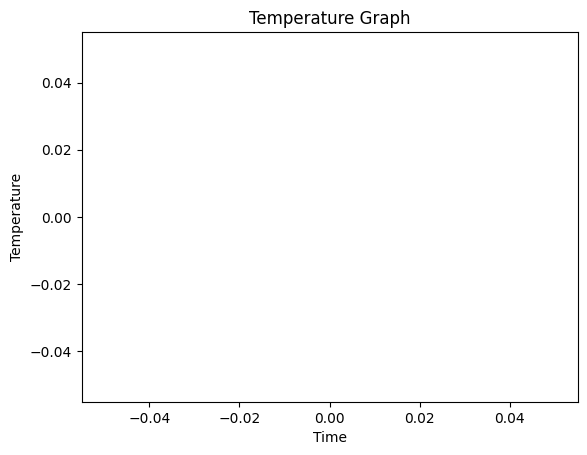


1. Add Light
2. Show Devices
3. Update Temperature
4. Save JSON
5. Load JSON
6. Plot Temperature
7. Exit

1. Add Light
2. Show Devices
3. Update Temperature
4. Save JSON
5. Load JSON
6. Plot Temperature
7. Exit
{'device': 'Main Thermostat', 'type': 'Thermostat', 'temperature': 25, 'status': False}
{'device': 'Cooling Fan', 'type': 'Fan', 'status': False}
{'device': 'Salom', 'type': 'Light', 'status': False, 'energy': 0}

1. Add Light
2. Show Devices
3. Update Temperature
4. Save JSON
5. Load JSON
6. Plot Temperature
7. Exit

1. Add Light
2. Show Devices
3. Update Temperature
4. Save JSON
5. Load JSON
6. Plot Temperature
7. Exit
{'device': 'Main Thermostat', 'type': 'Thermostat', 'temperature': 25, 'status': False}
{'device': 'Cooling Fan', 'type': 'Fan', 'status': False}
{'device': 'Salom', 'type': 'Light', 'status': False, 'energy': 0}

1. Add Light
2. Show Devices
3. Update Temperature
4. Save JSON
5. Load JSON
6. Plot Temperature
7. Exit
{'device': 'Main Thermostat', 'type': 'Therm

In [36]:
from abc import ABC, abstractmethod
import json
from datetime import datetime
import matplotlib.pyplot as plt

class Device(ABC):
    def __init__(self, name, power_per_hour):
        self.name= name
        self.is_on = False
        self.power_per_hour = power_per_hour
        self.total_hours = 0

    def turn_on(self):
        self.is_on = True
        print(f"{self.name} turned on")

    def turn_off(self):
        self.is_on = False
        print(f"{self.name} turned off")

    def calculate_energy(self):
        return  self.power_per_hour * self.total_hours
    
    @abstractmethod
    def status_report(self):
        pass


class Light(Device):
    def status_report(self):
        print({
            "device": self.name,
            "type": "Light",
            "status": self.is_on,
            "energy": self.calculate_energy()
        })  
        

class Thermostat(Device):
    def __init__(self, name, power_per_hour):
        super().__init__(name, power_per_hour) #parent classga murojat qilyabmiz

        self.temperature = 25
    def set_temperature(self, value):
        self.temperature = value

    def status_report(self):
        print({
            "device": self.name,
            "type": "Thermostat",
            "temperature": self.temperature,
            "status": self.is_on
        })

class Camera(Device):
    def status_report(self):
        print({
            "device": self.name,
            "type": "Camera",
            "status": self.is_on
        })    

class Alarm(Device):
    def status_report(self):
        print({
            "device": self.name,
            "type": "Alarm",
            "status": self.is_on
        })

class Fan(Device):
    def status_report(self):
        print({
            "device": self.name,
            "type": "Fan",
            "status": self.is_on
        })

class TemperatureObserver:
    def __init__(self, fan):
        self.fan = fan
    
    def update(self, temperature):
        if temperature > 30:
            if not self.fan.is_on:
                self.fan.turn_on()

                print("Fan automatically turned on")

class SmartHomeController:
    def __init__(self):
        self.devices = []
        self.temperature_history = []
        self.observers = []

    def add_device(self, device):
        self.devices.append(device)

    def add_observer(self, observer):
        self.observers.append(observer)

    def notify_observers(self, temperature):
        for observer in self.observers:
            observer.update(temperature)

    def show_all_status(self):
        for device in self.devices:
            device.status_report()

    def save_devices(self):
        data =[]
        for device in self.devices:
            info = {
                "name": device.name,
                "type": device.__class__.__name__,
                "is_on": device.is_on,
                "power_per_hour": device.power_per_hour,
                "total_hours": device.total_hours
            }

            if isinstance(device, Thermostat):
                info["temperature"] = device.temperature

            data.append(info)

        with open("devices.json", "w") as file:
            json.dump(data, file, indent=4)

        print("Devices saved")

    def load_devices(self):
        with open("devices.json", "r") as file:
            data = json.load(file)

        for item in data:
            device_type = item["type"]

            if device_type == "Thermostat":
                device = Thermostat(
                    item["name"],
                    item["power_per_hour"]
                )

                device.temperature = item["temperature"]

            elif device_type == "Camera":

                device = Camera(
                    item["name"],
                    item["power_per_hour"]
                )

            elif device_type == "Alarm":

                device = Alarm(
                    item["name"],
                    item["power_per_hour"]
                )

            else:

                device = Fan(
                    item["name"],
                    item["power_per_hour"]
                )

            device.is_on = item["is_on"]
            device.total_hours = item["total_hours"]

            self.devices.append(device)

        print("Devices loaded")
    
    def update_temperature(self, thermostat, temperature):
        thermostat.set_temperature(temperature)
        self.temperature_history.append(temperature)
        self.notify_observers(temperature)

    def plot_temperature_graph(self):
        plt.plot(self.temperature_history)
        plt.xlabel("Time")
        plt.ylabel("Temperature")
        plt.title("Temperature Graph")
        plt.show()

class SmartHomeCLI:

    def __init__(self):

        self.controller = SmartHomeController()

        self.thermostat = Thermostat("Main Thermostat", 2)

        self.fan = Fan("Cooling Fan", 3)

        self.controller.add_device(self.thermostat)
        self.controller.add_device(self.fan)

        observer = TemperatureObserver(self.fan)

        self.controller.add_observer(observer)

    def run(self):

        while True:

            print("\n1. Add Light")
            print("2. Show Devices")
            print("3. Update Temperature")
            print("4. Save JSON")
            print("5. Load JSON")
            print("6. Plot Temperature")
            print("7. Exit")

            choice = input("Choose: ")

            if choice == "1":

                name = input("Light name: ")

                light = Light(name, 1)

                self.controller.add_device(light)

            elif choice == "2":

                self.controller.show_all_status()

            elif choice == "3":

                temp = int(input("Temperature: "))

                self.controller.update_temperature(
                    self.thermostat,
                    temp
                )

            elif choice == "4":

                self.controller.save_devices()

            elif choice == "5":

                self.controller.load_devices()

            elif choice == "6":

                self.controller.plot_temperature_graph()

            elif choice == "7":

                break


cli = SmartHomeCLI()
cli.run()

Web Scraping CRM System

In [40]:
import requests
import csv 
from bs4 import BeautifulSoup
import json
import sqlite3
import logging
import time
from abc import ABC, abstractmethod

logging.basicConfig(filename="log.txt", level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")

def retry(func):
    def wrapper(*args, **kwargs):
        attempts = 3
        for i in range(attempts):
            try:
                return func(*args, **kwargs)
            except requests.exceptions.RequestException as e:
                logging.error(f"Retry {i+1}: {e}")

                print(f"Retrying...{i+1}")
                time.sleep(2) 
            
        print("Failed after retries")

    return wrapper

class Scraper(ABC):
    def __init__(self, url):
        self.url = url
        self.data = []

    @abstractmethod
    def scrape(self):
        pass

    def save_csv(self):
        with open("data.csv", "w", newline="") as file:
            writer = csv.writer(file)
            writer.writerow(["Title"])
            for item in self.data:
                writer.writerow([item])

        print("Csv saved")

    def save_json(self):
        with open("data.json", "w") as file:
            json.dump(self.data, file, indent=4)

        print("Json saved")

class NewScraper(Scraper):
    @retry
    def scrape(self):
        logging.info("NewScrapper Started")
        response = requests.get(self.url)
        soup = BeautifulSoup(response.text, "lxml")
        headlines = soup.find_all("h2")
        for headline in headlines:
            text = headline.text.strip()
            self.data.append(text)

        logging.info("Newscrapper Finished")
        return self.data
    
class ProductScraper(Scraper):

    @retry
    def scrape(self):
        logging.info("ProductScraper Started")
        response = requests.get(self.url)
        soup = BeautifulSoup(response.text, "lxml")
        products = soup.find_all("h2")
        for product in products:
            self.data.append(product.text.strip())

        logging.info("ProductScraper Finished")
        return self.data


class SocialScraper(Scraper):

    @retry
    def scrape(self):
        logging.info("SocialScraper Started")
        response = requests.get(self.url)
        soup = BeautifulSoup(response.text, "lxml")

        posts = soup.find_all("p")
        for post in posts:

            self.data.append(post.text.strip())
        logging.info("SocialScraper Finished")

        return self.data


class DataCleaner:

    def clean_text(self, text):
       text = text.lower()
       text = text.replace("\n", "")
       text = text.strip()

       return text

    def clean_data(self, data):
        cleaned = []
        for item in data:
            cleaned.append(self.clean_text(item))

        return cleaned
    
class LeadGenerator:

    def generate_leads(self, data):

        leads = []

        for item in data:

            lead = {
                "interest": item,
                "score": len(item)
            }

            leads.append(lead)

        return leads


class CRMCLI:

    def __init__(self):

        self.scraper = None

    def run(self):

        while True:

            print("\n1. News Scraper")
            print("2. Product Scraper")
            print("3. Social Scraper")
            print("4. Exit")

            choice = input("Choose: ")


            if choice == "1":

                url = input("News URL: ")

                self.scraper = NewScraper(url)

                data = self.scraper.scrape()

                cleaner = DataCleaner()

                cleaned = cleaner.clean_data(data)

                leads = LeadGenerator().generate_leads(cleaned)

                print("\nLeads:")
                print(leads)

                self.scraper.save_csv("news.csv")
                self.scraper.save_json("news.json")


            elif choice == "2":

                url = input("Product URL: ")

                self.scraper = ProductScraper(url)

                data = self.scraper.scrape()

                print(data)


            elif choice == "3":

                url = input("Social URL: ")

                self.scraper = SocialScraper(url)

                data = self.scraper.scrape()

                print(data)


            elif choice == "4":
                break


cli = CRMCLI()
cli.run()



1. News Scraper
2. Product Scraper
3. Social Scraper
4. Exit
['Kompaniyaning ish tamoyili', 'Bizning afzalliklarimiz']

1. News Scraper
2. Product Scraper
3. Social Scraper
4. Exit


Real Estate Data Analyzer

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from abc import ABC, abstractmethod
from sklearn.linear_model import LinearRegression



class Property(ABC):

    def __init__( self, property_id, district, area, price, rooms, sold):
        self.property_id = property_id
        self.district = district
        self.area = area
        self.price = price
        self.rooms = rooms
        self.sold = sold

    def calculate_price_per_m2(self):
      return self.price / self.area

    @abstractmethod
    def property_type(self):
        pass


class Apartment(Property):
    def property_type(self):
        return "Apartment"


class House(Property):
    def property_type(self):
        return "House"


class FilterStrategy(ABC):
    @abstractmethod
    def filter_data(self, df):
        pass


class PriceFilter(FilterStrategy):
    def __init__(self, max_price):
        self.max_price = max_price
    def filter_data(self, df):
        return df[df["price"] <= self.max_price]



class AreaFilter(FilterStrategy):
    def __init__(self, min_area):
        self.min_area = min_area
    def filter_data(self, df):
        return df[df["area"] >= self.min_area]


class DistrictFilter(FilterStrategy):
    def __init__(self, district):
        self.district = district
    def filter_data(self, df):
        return df[df["district"] == self.district]



class RoomFilter(FilterStrategy):
    def __init__(self, rooms):
        self.rooms = rooms
    def filter_data(self, df):
        return df[df["rooms"] == self.rooms]



class RealEstateAnalyzer:
    def __init__(self, csv_file):
        self.df = pd.read_csv(csv_file)


    def show_statistics(self):
        print("\nAverage Price:")
        print(self.df["price"].mean())

        print("\nMost Expensive District:")
        print(self.df.groupby("district")["price"].mean().idxmax())

        print("\nSold Properties:")
        print(self.df[self.df["sold"] == True].shape[0])

    def apply_filter(self, strategy):

        filtered = strategy.filter_data(self.df)
        return filtered


    def export_excel(self, data, filename):

        data.to_excel(filename, index=False)

        print("Excel exported")


    def visualize(self):

        sns.histplot(self.df["price"], kde=True)
        plt.title("Price Distribution")
        plt.show()

        sns.barplot( x="district", y="price", data=self.df)
        plt.title("District Prices")
        plt.show()

    # MACHINE LEARNING
    def price_predictor(self):

        X = self.df[["area", "rooms"]]

        y = self.df["price"]

        model = LinearRegression()

        model.fit(X, y)

        predicted = model.predict([[120, 3]])

        print("\nPredicted Price:")
        print(predicted[0])



class RealEstateCLI:

    def __init__(self):

        self.analyzer = RealEstateAnalyzer(
            "properties.csv")

    def run(self):
        while True:
            print("\n1. Show Statistics")
            print("2. Filter By Price")
            print("3. Filter By Area")
            print("4. Filter By District")
            print("5. Filter By Rooms")
            print("6. Visualize")
            print("7. Predict Price")
            print("8. Exit")

            choice = input("Choose: ")

  
            if choice == "1":
                self.analyzer.show_statistics()

            elif choice == "2":

                max_price = float(
                    input("Max price: "))

                strategy = PriceFilter(max_price)

                result = self.analyzer.apply_filter(
                    strategy)

                print(result)

                self.analyzer.export_excel(
                    result,
                    "price_filter.xlsx")


            elif choice == "3":
                min_area = float(
                    input("Min area: ")
                )

                strategy = AreaFilter(min_area)

                result = self.analyzer.apply_filter(
                    strategy)

                print(result)


            elif choice == "4":
                district = input("District: ")

                strategy = DistrictFilter(district)

                result = self.analyzer.apply_filter(
                    strategy)

                print(result)

            elif choice == "5":

                rooms = int(
                    input("Rooms: "))

                strategy = RoomFilter(rooms)

                result = self.analyzer.apply_filter(strategy)
                print(result)

     
            elif choice == "6":
                self.analyzer.visualize()

            elif choice == "7":
                self.analyzer.price_predictor()

    
            elif choice == "8":
                break


cli = RealEstateCLI()
cli.run()


1. Show Statistics
2. Filter By Price
3. Filter By Area
4. Filter By District
5. Filter By Rooms
6. Visualize
7. Predict Price
8. Exit


Text-Based RPG Game Engine

In [53]:
import random 
import json
import logging
from abc import ABC, abstractmethod

logging.basicConfig(filename="log.txt", level=logging.INFO, format="%(asctime)s - %(message)s")

class PlayerState(ABC):
    @abstractmethod
    def state_name(self):
        pass

    @abstractmethod
    def health_effect(self):
        pass

class Healthy(PlayerState):
    def state_name(self):
        return "Healthy"
    
    def health_effect(self):
        return 1.0
    
class Poisoned(PlayerState):
    def state_name(self):
        return "Poisoned"
    
    def health_effect(self):
        return 0.7
    
class Dead(PlayerState):
    def state_name(self):
        return "Dead"
    
    def health_effect(self):
        return 0
    
class Item:
    def __init__(self, name, heal):
        self.name = name
        self.heal = heal

class Character:
    def __init__(self, name, health, attack_power, defense):
        self.name = name
        self.health = health
        self.attack_power = attack_power
        self.defense = defense
        
    def attack(self, target):
        damage = self.attack_power - target.defense
        if damage < 0:
            damage = 0

        target.health -= damage
        print(f"{self.name} attacked {target.name}")
        print(f"Damage: {damage}")
        logging.info(f"{self.name} attacked {target.name} ({damage})")

    def defend(self):
       self.defense += 5
       print(f"{self.name} increased defense")
       logging.info(f"{self.name} defended")


class Player(Character):
    def __init__(self,name,health,attack_power,defense):
         super().__init__(name, health, attack_power, defense)
         self.inventory = []
         self.state = Healthy()


    def use_item(self, item):
        self.health += item.heal
        print(f"{self.name} used {item.name}")
        logging.info(
            f"{self.name} used {item.name}")

  
    def change_state(self, new_state):
        self.state = new_state
        print(f"{self.name} state: " f"{self.state.state_name()}")
        logging.info(
            f"{self.name} changed state "
            f"to {self.state.state_name()}"
        )



class Enemy(Character):
    def choose_action(self):
        if self.health < 20:
            return "retreat"
        return "attack"


class Quest:
    def __init__(self):
        quest_types = [
            "Kill Monster",
            "Find Item",
            "Explore Zone"]

        self.quest = random.choice(
            quest_types
        )
    def show_quest(self):
        print(f"Quest: {self.quest}")


class World:
    def __init__(self):
        self.players = []
        self.enemies = []
        self.quests = []

    def add_player(self, player):
        self.players.append(player)
    def add_enemy(self, enemy):
        self.enemies.append(enemy)
    def generate_quest(self):
        quest = Quest()
        self.quests.append(quest)
        return quest
    

    def save_game(self):
        data = {
            "players": [
                {"name": p.name,"health": p.health,"attack": p.attack_power,"defense": p.defense,"state": p.state.state_name()}
                for p in self.players]}

        with open("savegame.json","w") as file:
            json.dump(data, file, indent=4)
        print("Game saved")


    def load_game(self):
        with open("savegame.json","r") as file:
            data = json.load(file)
        print(data)


world = World()
player = Player("Knight",100,25,10)


enemy = Enemy("Goblin",50,15,5)


potion = Item("Health Potion",30)


world.add_player(player)
world.add_enemy(enemy)

quest = world.generate_quest()
quest.show_quest()


player.attack(enemy)
enemy.attack(player)


player.use_item(potion)
player.change_state(Poisoned())

print(enemy.choose_action())

world.save_game()
world.load_game()    

Quest: Find Item
Knight attacked Goblin
Damage: 20
Goblin attacked Knight
Damage: 5
Knight used Health Potion
Knight state: Poisoned
attack
Game saved
{'players': [{'name': 'Knight', 'health': 125, 'attack': 25, 'defense': 10, 'state': 'Poisoned'}]}
